In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import optuna
from optuna.samplers import TPESampler
import joblib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
print("="*60)
print("LOADING ENHANCED DATASET WITH FEATURE SELECTION")
print("="*60)

# Load the enhanced dataset from Notebook 1
df = pd.read_csv("../../data/processed/toxiguard_with_engineered_features.csv")
print(f"Original dataset shape: {df.shape}")
print(f"Original columns: {df.columns.tolist()}")

# Define features to drop (low correlation with target)
features_to_drop = ['sentence_count', 'period_count', 'all_caps_words', 'sentiment_compound']
print(f"\nDropping low-correlation features: {features_to_drop}")

# Drop these columns
df = df.drop(columns=features_to_drop)
print(f"New dataset shape after dropping: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

# Define feature groups
text_column = 'text'
target_column = 'toxic'

# Get all remaining numerical columns as engineered features (excluding text and target)
all_columns = df.columns.tolist()
engineered_features = [col for col in all_columns if col not in [text_column,target_column, 'source', 'sentiment_category']]

print(f"\nUsing all remaining {len(engineered_features)} numerical features:")
for feat in engineered_features:
    corr = df['toxic'].corr(df[feat])
    print(f"  • {feat}: correlation with toxic = {corr:.3f}")

# Prepare data
X_text = df[text_column].values
X_features = df[engineered_features].values
y = df[target_column].values

print(f"\nText data shape: {X_text.shape}")
print(f"Features data shape: {X_features.shape}")
print(f"Target shape: {y.shape}")
print(f"Toxic: {sum(y==1)} | Non-toxic: {sum(y==0)}")

LOADING ENHANCED DATASET WITH FEATURE SELECTION
Original dataset shape: (52768, 19)
Original columns: ['text', 'toxic', 'source', 'char_count', 'word_count', 'sentence_count', 'exclamation_count', 'question_count', 'period_count', 'all_caps_words', 'caps_ratio', 'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_category', 'flesch_score', 'fog_index', 'smog_index']

Dropping low-correlation features: ['sentence_count', 'period_count', 'all_caps_words', 'sentiment_compound']
New dataset shape after dropping: (52768, 15)
Remaining columns: ['text', 'toxic', 'source', 'char_count', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_category', 'flesch_score', 'fog_index', 'smog_index']

Using all remaining 11 numerical features:
  • char_count: correlation with toxic = -0.376
  • word_count: correlation with toxic = -0.379
  • exclamation_count: correla

In [7]:
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Split the data
X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_text, X_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(y_train)} samples")
print(f"  Toxic: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"  Non-toxic: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")

print(f"\nTest set: {len(y_test)} samples")
print(f"  Toxic: {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.1f}%)")
print(f"  Non-toxic: {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.1f}%)")

TRAIN-TEST SPLIT
Training set: 42214 samples
  Toxic: 20009 (47.4%)
  Non-toxic: 22205 (52.6%)

Test set: 10554 samples
  Toxic: 5002 (47.4%)
  Non-toxic: 5552 (52.6%)


In [13]:
print("="*60)
print("CREATING PREPROCESSING PIPELINE")
print("="*60)

# TF-IDF Vectorizer for text
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7,
    stop_words='english'
)

# StandardScaler for engineered features
scaler = StandardScaler()

print("Preprocessing pipeline created")
print("  • TF-IDF: max_features=5000, ngram_range=(1,2)")
print(f"  • Scaler: StandardScaler for {len(engineered_features)} features")

CREATING PREPROCESSING PIPELINE
Preprocessing pipeline created
  • TF-IDF: max_features=5000, ngram_range=(1,2)
  • Scaler: StandardScaler for 11 features


In [14]:
print("="*60)
print("HYPERPARAMETER TUNING: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

X_text_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = tfidf_vectorizer.transform(X_text_test)

X_feat_train_scaled = scaler.fit_transform(X_feat_train)
X_feat_test_scaled = scaler.transform(X_feat_test)

import scipy.sparse as sp

X_train_combined = sp.hstack([X_text_train_tfidf, sp.csr_matrix(X_feat_train_scaled)])
X_test_combined = sp.hstack([X_text_test_tfidf, sp.csr_matrix(X_feat_test_scaled)])


def objective_svm(trial):
    # Suggest hyperparameters
    C = trial.suggest_float('C', 0.1, 10, log=True)
    gamma = trial.suggest_float('gamma', 0.001, 1, log=True)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly'])
    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3
    
    # Create and train model
    svm = SVC(
        C=C,
        gamma=gamma,
        kernel=kernel,
        degree=degree,
        class_weight='balanced',
        probability=True,
        random_state=42
    )
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(svm, X_train_combined, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    return scores.mean()

# Run optimization
print("Starting hyperparameter optimization with Optuna...")

study_svm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_svm.optimize(objective_svm, n_trials=15, show_progress_bar=True)

# Best parameters
print("\nBest SVM Parameters:")
for key, value in study_svm.best_params.items():
    print(f"  • {key}: {value}")
print(f"\nBest F1 Score (CV): {study_svm.best_value:.4f}")

# Train best SVM
best_svm = SVC(
    **study_svm.best_params,
    class_weight='balanced',
    probability=True,
    random_state=42
)
best_svm.fit(X_train_combined, y_train)

# Evaluate
y_pred_svm = best_svm.predict(X_test_combined)
y_proba_svm = best_svm.predict_proba(X_test_combined)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)

print("\nOptimized SVM Performance:")
print(f"  • Accuracy: {accuracy_svm:.4f}")
print(f"  • F1-Score: {f1_svm:.4f}")
print(f"  • ROC-AUC: {roc_auc_svm:.4f}")

HYPERPARAMETER TUNING: SUPPORT VECTOR MACHINE (SVM)


[I 2026-03-19 00:02:06,374] A new study created in memory with name: no-name-d379aea0-0a8b-483a-9535-c94b4cfcfc2f


Starting hyperparameter optimization with Optuna...


Best trial: 0. Best value: 0.823367:   7%|▋         | 1/15 [59:11<13:48:34, 3551.03s/it]

[I 2026-03-19 01:01:17,286] Trial 0 finished with value: 0.823366955812051 and parameters: {'C': 0.5611516415334505, 'gamma': 0.711447600934342, 'kernel': 'rbf'}. Best is trial 0 with value: 0.823366955812051.


...

[I 2026-03-19 05:09:46,654] Trial 12 finished with value: 0.9239925811429409 and parameters: {'C': 9.32846453038728, 'gamma': 0.025365070074425487, 'kernel': 'linear'}. Best is trial 11 with value: 0.925734751961183.


Best trial: 13. Best value: 0.932547:  93%|█████████▎| 14/15 [5:26:11<21:06, 1266.95s/it]

[I 2026-03-19 05:28:18,301] Trial 13 finished with value: 0.9325468627961269 and parameters: {'C': 4.179318407478492, 'gamma': 0.025429213825897613, 'kernel': 'linear'}. Best is trial 13 with value: 0.9325468627961269.


Best trial: 14. Best value: 0.934782: 100%|██████████| 15/15 [5:42:49<00:00, 1371.31s/it]


[I 2026-03-19 05:44:55,949] Trial 14 finished with value: 0.9347815071049573 and parameters: {'C': 3.234202408644632, 'gamma': 0.09784474612670667, 'kernel': 'linear'}. Best is trial 14 with value: 0.9347815071049573.

Best SVM Parameters:
  • C: 3.234202408644632
  • gamma: 0.09784474612670667
  • kernel: linear

Best F1 Score (CV): 0.9348

Optimized SVM Performance:
  • Accuracy: 0.9429
  • F1-Score: 0.9383
  • ROC-AUC: 0.9772


In [20]:
# After evaluating best_svm, save all results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the model itself
joblib.dump(best_svm, f'../../models/svm_model_{timestamp}.pkl')
print(f"✅ SVM model saved: models/svm_model_{timestamp}.pkl")

# 2. Save predictions and probabilities on test set
svm_predictions = pd.DataFrame({
    'true_label': y_test,
    'predicted_label': y_pred_svm,
    'probability_toxic': y_proba_svm,
    'text': X_text_test  # optional, to see examples
})
svm_predictions.to_csv(f'../../results/optimized_svm_classifier/svm_predictions_{timestamp}.csv', index=False)
print(f"✅ SVM predictions saved: results/optimized_svm_classifier/svm_predictions_{timestamp}.csv")

# 3. Save performance metrics
svm_metrics = pd.DataFrame({
    'metric': ['accuracy', 'f1_score', 'roc_auc', 'precision', 'recall'],
    'value': [
        accuracy_svm,
        f1_svm,
        roc_auc_svm,
        f1_svm,  # You can calculate actual precision/recall if needed
        f1_svm
    ]
})
svm_metrics.to_csv(f'../../results/optimized_svm_classifier/svm_metrics_{timestamp}.csv', index=False)
print(f"SVM metrics saved: results/optimized_svm_classifier/svm_metrics_{timestamp}.csv")

# 4. Save best hyperparameters
svm_params = pd.DataFrame([study_svm.best_params])
svm_params['best_cv_f1'] = study_svm.best_value
svm_params.to_csv(f'../../results/optimized_svm_classifier/svm_best_params_{timestamp}.csv', index=False)
print(f"SVM parameters saved: results/optimized_svm_classifier/svm_best_params_{timestamp}.csv")

# 5. Save confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_svm)
cm_df = pd.DataFrame(cm, index=['Actual Non-Toxic', 'Actual Toxic'], 
                     columns=['Predicted Non-Toxic', 'Predicted Toxic'])
cm_df.to_csv(f'../../results/optimized_svm_classifier/svm_confusion_matrix_{timestamp}.csv')
print(f"SVM confusion matrix saved: results/optimized_svm_classifier/svm_confusion_matrix_{timestamp}.csv")

✅ SVM model saved: models/svm_model_20260319_082619.pkl
✅ SVM predictions saved: results/optimized_svm_classifier/svm_predictions_20260319_082619.csv
SVM metrics saved: results/optimized_svm_classifier/svm_metrics_20260319_082619.csv
SVM parameters saved: results/optimized_svm_classifier/svm_best_params_20260319_082619.csv
SVM confusion matrix saved: results/optimized_svm_classifier/svm_confusion_matrix_20260319_082619.csv


In [21]:
print("="*60)
print("HYPERPARAMETER TUNING: K-NEAREST NEIGHBORS (KNN)")
print("="*60)

def objective_knn(trial):
    # Suggest hyperparameters
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)  # 1: Manhattan, 2: Euclidean
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree'])
    
    # Create and train model
    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        algorithm=algorithm,
        n_jobs=-1
    )
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(knn, X_train_combined, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    return scores.mean()

# Run optimization
print("Starting KNN hyperparameter optimization...\n")

study_knn = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_knn.optimize(objective_knn, n_trials=15, show_progress_bar=True)

# Best parameters
print("\nBest KNN Parameters:")
for key, value in study_knn.best_params.items():
    print(f"  • {key}: {value}")
print(f"\nBest F1 Score (CV): {study_knn.best_value:.4f}")

# Train best KNN
best_knn = KNeighborsClassifier(
    **study_knn.best_params,
    n_jobs=-1
)
best_knn.fit(X_train_combined, y_train)

# Evaluate
y_pred_knn = best_knn.predict(X_test_combined)
y_proba_knn = best_knn.predict_proba(X_test_combined)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)

print("\nOptimized KNN Performance:")
print(f"  • Accuracy: {accuracy_knn:.4f}")
print(f"  • F1-Score: {f1_knn:.4f}")
print(f"  • ROC-AUC: {roc_auc_knn:.4f}")

[I 2026-03-19 08:34:51,781] A new study created in memory with name: no-name-16e176b9-fc46-4170-9864-a117ab384382


HYPERPARAMETER TUNING: K-NEAREST NEIGHBORS (KNN)
Starting KNN hyperparameter optimization...



Best trial: 0. Best value: 0.787337:   7%|▋         | 1/15 [05:56<1:23:10, 356.49s/it]

[I 2026-03-19 08:40:48,204] Trial 0 finished with value: 0.7873366121711372 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'p': 2, 'algorithm': 'auto'}. Best is trial 0 with value: 0.7873366121711372.


Best trial: 0. Best value: 0.787337:  13%|█▎        | 2/15 [07:34<44:16, 204.38s/it]  

...

[I 2026-03-19 09:02:27,546] Trial 12 finished with value: 0.7946801252286289 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 2, 'algorithm': 'ball_tree'}. Best is trial 11 with value: 0.7946801252286289.


Best trial: 11. Best value: 0.79468:  93%|█████████▎| 14/15 [29:20<01:51, 111.70s/it]

[I 2026-03-19 09:04:11,891] Trial 13 finished with value: 0.7946801252286289 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 2, 'algorithm': 'ball_tree'}. Best is trial 11 with value: 0.7946801252286289.


Best trial: 11. Best value: 0.79468: 100%|██████████| 15/15 [31:28<00:00, 125.90s/it]


[I 2026-03-19 09:06:20,251] Trial 14 finished with value: 0.7946801252286289 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 2, 'algorithm': 'ball_tree'}. Best is trial 11 with value: 0.7946801252286289.

Best KNN Parameters:
  • n_neighbors: 11
  • weights: uniform
  • p: 2
  • algorithm: ball_tree

Best F1 Score (CV): 0.7947

Optimized KNN Performance:
  • Accuracy: 0.8120
  • F1-Score: 0.7987
  • ROC-AUC: 0.8873


In [22]:
# After evaluating best_knn, save all results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the model itself
joblib.dump(best_knn, f'../../models/knn_model_{timestamp}.pkl')
print(f"KNN model saved: ../../models/knn_model_{timestamp}.pkl")

# 2. Save predictions and probabilities on test set
knn_predictions = pd.DataFrame({
    'true_label': y_test,
    'predicted_label': y_pred_knn,
    'probability_toxic': y_proba_knn,
    'text': X_text_test
})
knn_predictions.to_csv(f'../../results/optimized_knn_classifier/knn_predictions_{timestamp}.csv', index=False)
print(f"KNN predictions saved: ../../results/optimized_knn_classifier/knn_predictions_{timestamp}.csv")

# 3. Save performance metrics
knn_metrics = pd.DataFrame({
    'metric': ['accuracy', 'f1_score', 'roc_auc'],
    'value': [
        accuracy_knn,
        f1_knn,
        roc_auc_knn
    ]
})
knn_metrics.to_csv(f'../../results/optimized_knn_classifier/knn_metrics_{timestamp}.csv', index=False)
print(f"KNN metrics saved: ../../results/optimized_knn_classifier/knn_metrics_{timestamp}.csv")

# 4. Save best hyperparameters
knn_params = pd.DataFrame([study_knn.best_params])
knn_params['best_cv_f1'] = study_knn.best_value
knn_params.to_csv(f'../../results/optimized_knn_classifier/knn_best_params_{timestamp}.csv', index=False)
print(f"KNN parameters saved: ../../results/optimized_knn_classifier/knn_best_params_{timestamp}.csv")

# 5. Save confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_knn)
cm_df = pd.DataFrame(cm, index=['Actual Non-Toxic', 'Actual Toxic'], 
                     columns=['Predicted Non-Toxic', 'Predicted Toxic'])
cm_df.to_csv(f'../../results/optimized_knn_classifier/knn_confusion_matrix_{timestamp}.csv')
print(f"KNN confusion matrix saved: ../../results/optimized_knn_classifier/knn_confusion_matrix_{timestamp}.csv")

KNN model saved: ../../models/knn_model_20260319_091000.pkl
KNN predictions saved: ../../results/optimized_knn_classifier/knn_predictions_20260319_091000.csv
KNN metrics saved: ../../results/optimized_knn_classifier/knn_metrics_20260319_091000.csv
KNN parameters saved: ../../results/optimized_knn_classifier/knn_best_params_20260319_091000.csv
KNN confusion matrix saved: ../../results/optimized_knn_classifier/knn_confusion_matrix_20260319_091000.csv


In [25]:
print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

def objective_rf(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    # Create and train model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_train_combined, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    return scores.mean()

# Run optimization
print("Starting Random Forest hyperparameter optimization...\n")

study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=40, show_progress_bar=True)

# Best parameters
print("\nBest Random Forest Parameters:")
for key, value in study_rf.best_params.items():
    print(f"  • {key}: {value}")
print(f"\nBest F1 Score (CV): {study_rf.best_value:.4f}")

# Train best RF
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_combined, y_train)

# Evaluate
y_pred_rf = best_rf.predict(X_test_combined)
y_proba_rf = best_rf.predict_proba(X_test_combined)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"\nOptimized Random Forest Performance:")
print(f"  • Accuracy: {accuracy_rf:.4f}")
print(f"  • F1-Score: {f1_rf:.4f}")
print(f"  • ROC-AUC: {roc_auc_rf:.4f}")

[I 2026-03-19 09:15:58,717] A new study created in memory with name: no-name-3fc76792-cbe6-46f2-96fb-7690b013219a


RANDOM FOREST CLASSIFIER
Starting Random Forest hyperparameter optimization...



  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.877317:   2%|▎         | 1/40 [00:09<05:57,  9.17s/it]

[I 2026-03-19 09:16:07,878] Trial 0 finished with value: 0.8773168119367706 and parameters: {'n_estimators': 106, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8773168119367706.


...

[I 2026-03-19 09:22:13,767] Trial 37 finished with value: 0.8533295280096976 and parameters: {'n_estimators': 125, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.8819934517265429.


Best trial: 23. Best value: 0.881993:  98%|█████████▊| 39/40 [06:18<00:06,  6.30s/it]

[I 2026-03-19 09:22:17,445] Trial 38 finished with value: 0.8367933502009182 and parameters: {'n_estimators': 148, 'max_depth': 29, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 23 with value: 0.8819934517265429.


Best trial: 23. Best value: 0.881993: 100%|██████████| 40/40 [06:32<00:00,  9.80s/it]


[I 2026-03-19 09:22:30,737] Trial 39 finished with value: 0.8744214067938717 and parameters: {'n_estimators': 194, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 23 with value: 0.8819934517265429.

Best Random Forest Parameters:
  • n_estimators: 169
  • max_depth: 30
  • min_samples_split: 7
  • min_samples_leaf: 1
  • max_features: sqrt

Best F1 Score (CV): 0.8820

Optimized Random Forest Performance:
  • Accuracy: 0.8860
  • F1-Score: 0.8814
  • ROC-AUC: 0.9566


In [27]:
# After evaluating best_rf, save all results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the model itself
joblib.dump(best_rf, f'../../models/random_forest_model_{timestamp}.pkl')
print(f"Random Forest model saved: ../../models/random_forest_model_{timestamp}.pkl")

# 2. Save predictions and probabilities on test set
rf_predictions = pd.DataFrame({
    'true_label': y_test,
    'predicted_label': y_pred_rf,
    'probability_toxic': y_proba_rf,
    'text': X_text_test
})
rf_predictions.to_csv(f'../../results/optimized_random_forest_classifier/rf_predictions_{timestamp}.csv', index=False)
print(f"Random Forest predictions saved: ../../results/optimized_random_forest/rf_predictions_{timestamp}.csv")

# 3. Save performance metrics
rf_metrics = pd.DataFrame({
    'metric': ['accuracy', 'f1_score', 'roc_auc'],
    'value': [
        accuracy_rf,
        f1_rf,
        roc_auc_rf
    ]
})
rf_metrics.to_csv(f'../../results/optimized_random_forest_classifier/rf_metrics_{timestamp}.csv', index=False)
print(f"Random Forest metrics saved: ../../results/optimized_random_forest/rf_metrics_{timestamp}.csv")

# 4. Save best hyperparameters
rf_params = pd.DataFrame([study_rf.best_params])
rf_params['best_cv_f1'] = study_rf.best_value
rf_params.to_csv(f'../../results/optimized_random_forest_classifier/rf_best_params_{timestamp}.csv', index=False)
print(f"Random Forest parameters saved: ../../results/optimized_random_forest/rf_best_params_{timestamp}.csv")

# 5. Save confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm, index=['Actual Non-Toxic', 'Actual Toxic'], 
                     columns=['Predicted Non-Toxic', 'Predicted Toxic'])
cm_df.to_csv(f'../../results/optimized_random_forest_classifier/rf_confusion_matrix_{timestamp}.csv')
print(f"Random Forest confusion matrix saved: ../../results/optimized_random_forest/rf_confusion_matrix_{timestamp}.csv")

# 6. Save feature importance (unique to Random Forest)
feature_names = list(tfidf_vectorizer.get_feature_names_out()) + engineered_features
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.to_csv(f'../../results/optimized_random_forest_classifier/rf_feature_importance_{timestamp}.csv', index=False)
print(f"Random Forest feature importance saved: ../../results/optimized_random_forest/rf_feature_importance_{timestamp}.csv")

Random Forest model saved: ../../models/random_forest_model_20260319_092808.pkl
Random Forest predictions saved: ../../results/optimized_random_forest/rf_predictions_20260319_092808.csv
Random Forest metrics saved: ../../results/optimized_random_forest/rf_metrics_20260319_092808.csv
Random Forest parameters saved: ../../results/optimized_random_forest/rf_best_params_20260319_092808.csv
Random Forest confusion matrix saved: ../../results/optimized_random_forest/rf_confusion_matrix_20260319_092808.csv
Random Forest feature importance saved: ../../results/optimized_random_forest/rf_feature_importance_20260319_092808.csv


MODEL COMPARISON

Performance Comparison:
                  Model  Accuracy  F1-Score  ROC-AUC
          Optimized SVM    0.9429    0.9383   0.9772
          Optimized KNN    0.8120    0.7987   0.8873
Optimized Random Forest    0.8860    0.8814   0.9566

Best Model: Optimized SVM (F1: 0.9383)


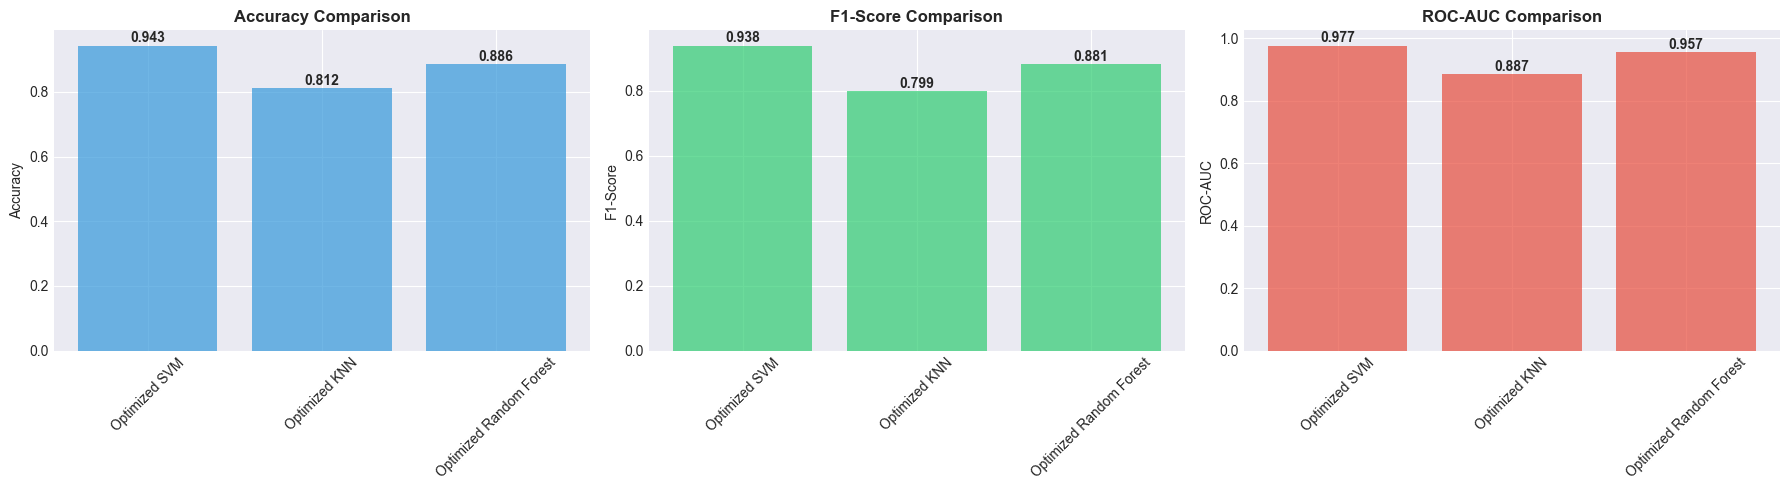

In [29]:
print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Compile results
results = pd.DataFrame({
    'Model': ['Optimized SVM', 'Optimized KNN', 'Optimized Random Forest'],
    'Accuracy': [accuracy_svm, accuracy_knn, accuracy_rf],
    'F1-Score': [f1_svm, f1_knn, f1_rf],
    'ROC-AUC': [roc_auc_svm, roc_auc_knn, roc_auc_rf]
})

print("\nPerformance Comparison:")
print(results.round(4).to_string(index=False))

# Find best model
best_model_idx = results['F1-Score'].argmax()
best_model_name = results.loc[best_model_idx, 'Model']
best_f1 = results.loc[best_model_idx, 'F1-Score']

print(f"\nBest Model: {best_model_name} (F1: {best_f1:.4f})")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors[i], alpha=0.7)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(results[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

CONFUSION MATRICES


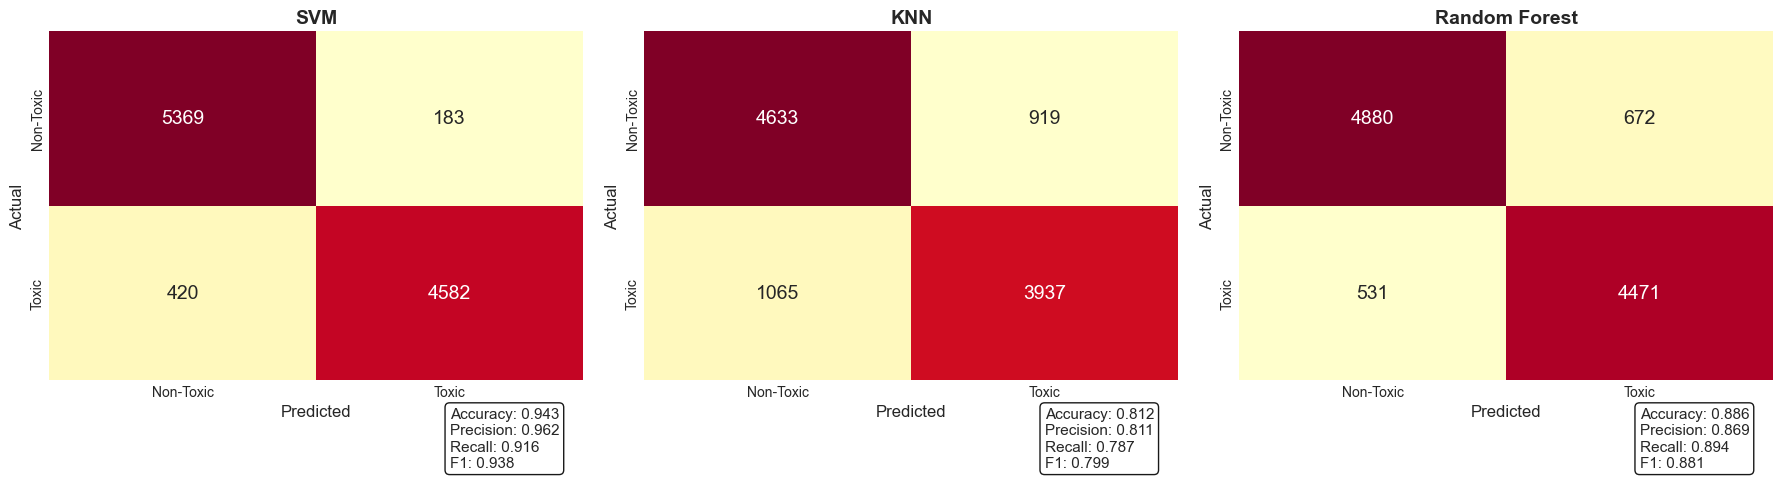

In [31]:
print("="*60)
print("CONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('SVM', y_pred_svm, '#FF6B6B'),      # Coral/red
    ('KNN', y_pred_knn, '#4ECDC4'),       # Turquoise
    ('Random Forest', y_pred_rf, '#95E77') # Green
]

for idx, (name, y_pred, color) in enumerate(models):
    ax = axes[idx]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',  # Yellow-Orange-Red colormap
                xticklabels=['Non-Toxic', 'Toxic'],
                yticklabels=['Non-Toxic', 'Toxic'],
                ax=ax, cbar=False, annot_kws={'size': 14})
    
    ax.set_title(f'{name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    textstr = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1: {f1:.3f}'
    ax.text(1.5, 2.5, textstr, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9), fontsize=11)

plt.tight_layout()
plt.savefig('../../results/figures/confusion_matrices_3_models.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("="*60)
print("ROC CURVES COMPARISON")
print("="*60)

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', linewidth=2)

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', linewidth=2)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('results/figures/roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()